# Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

# Task 1 — Data Preprocessing & Exploratory Data Analysis (EDA)

In [3]:
# DATA LOADING
df = pd.read_csv("anime.csv")
print("Dataset loaded successfully.")
print(f"Shape : {df.shape}  ({df.shape[0]} anime titles, {df.shape[1]} columns)")

Dataset loaded successfully.
Shape : (12294, 7)  (12294 anime titles, 7 columns)


In [4]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [6]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


In [7]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


In [8]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [9]:
print("=== Type Distribution ===")
print(df["type"].value_counts())
print("\n=== Top 15 Genre Combinations ===")
print(df["genre"].value_counts().head(15))
print("\n=== Rating Distribution (top 10 values) ===")
print(df["rating"].value_counts().head(10))

=== Type Distribution ===
type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64

=== Top 15 Genre Combinations ===
genre
Hentai                   823
Comedy                   523
Music                    301
Kids                     199
Comedy, Slice of Life    179
Dementia                 137
Fantasy, Kids            128
Fantasy                  114
Comedy, Kids             112
Drama                    107
Drama, Kids              105
Slice of Life             99
Kids, Music               95
Comedy, Fantasy, Kids     81
Adventure, Kids           80
Name: count, dtype: int64

=== Rating Distribution (top 10 values) ===
rating
6.00    141
7.00     99
6.50     90
6.25     84
5.00     76
6.75     72
6.67     68
5.67     67
6.38     67
6.80     67
Name: count, dtype: int64


# VISUALISATION 1 — Anime Type Distribution (Bar Chart)

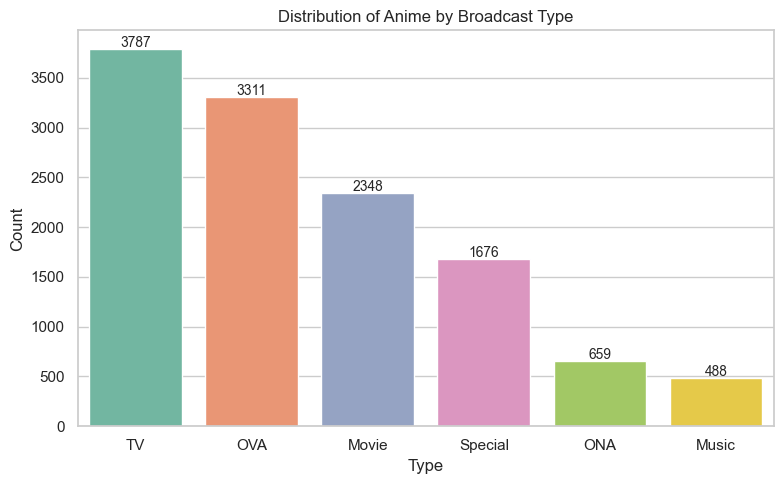

In [10]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x="type", data=df,
                   order=df["type"].value_counts().index, palette="Set2")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                ha="center", fontsize=10)
plt.title("Distribution of Anime by Broadcast Type")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# VISUALISATION 2 — Rating Distribution (Histogram + KDE)

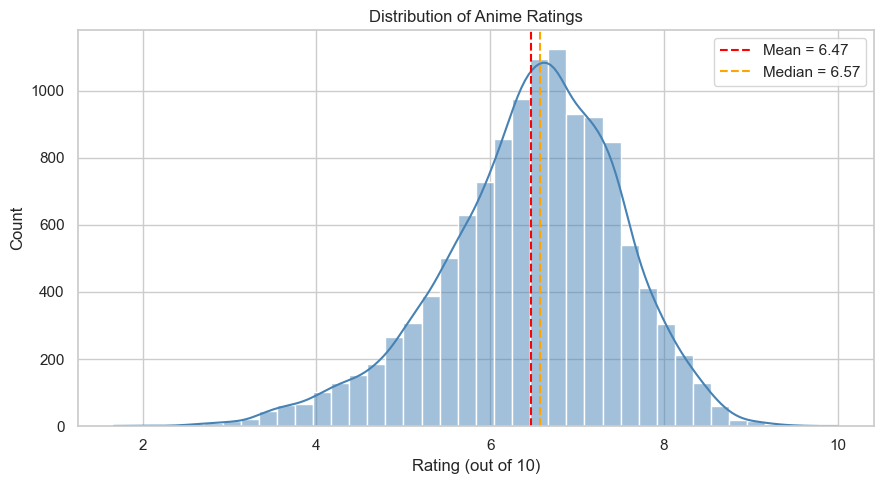

In [11]:
plt.figure(figsize=(9, 5))
sns.histplot(df["rating"].dropna(), kde=True, bins=40, color="steelblue")
plt.axvline(df["rating"].mean(), color="red", linestyle="--",
            label=f"Mean = {df['rating'].mean():.2f}")
plt.axvline(df["rating"].median(), color="orange", linestyle="--",
            label=f"Median = {df['rating'].median():.2f}")
plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating (out of 10)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# VISUALISATION 3 — Members Distribution (Log Scale)

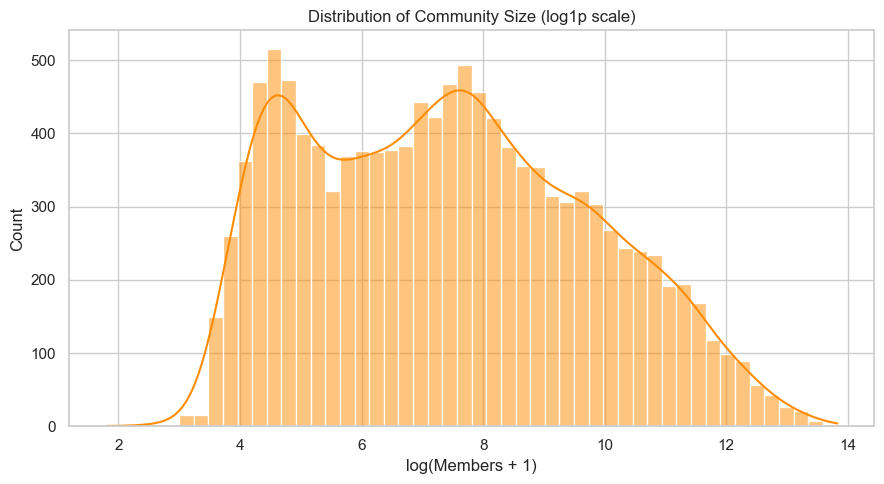

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(np.log1p(df["members"]), kde=True, bins=50, color="darkorange")
plt.title("Distribution of Community Size (log1p scale)")
plt.xlabel("log(Members + 1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# VISUALISATION 4 — Top 20 Most Common Individual Genres

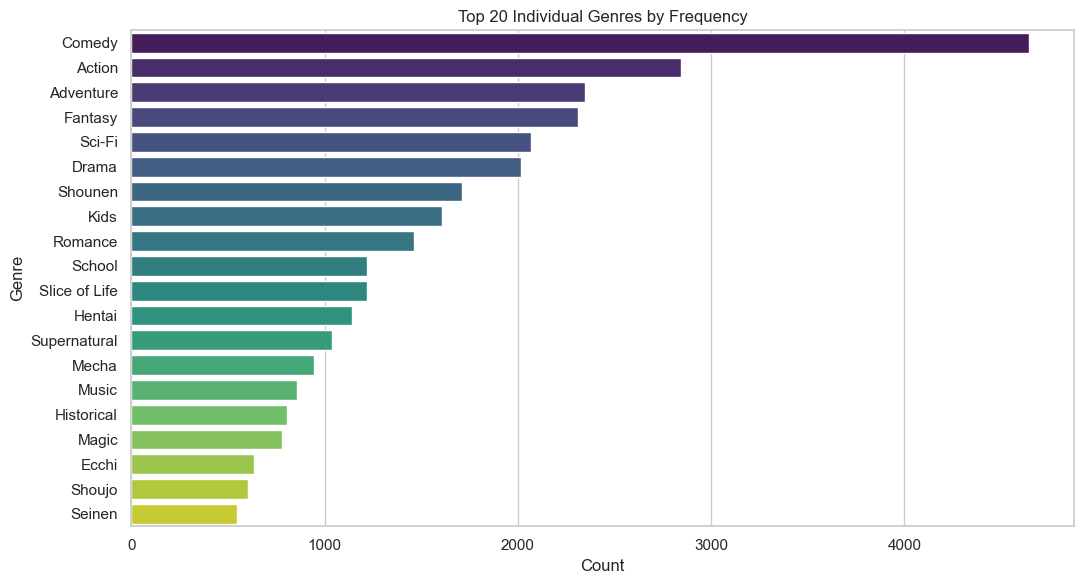

In [13]:
genre_exploded = df["genre"].dropna().str.split(", ").explode()
top_genres     = genre_exploded.value_counts().head(20)

plt.figure(figsize=(11, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 20 Individual Genres by Frequency")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

# VISUALISATION 5 — Rating by Anime Type (Box Plot)

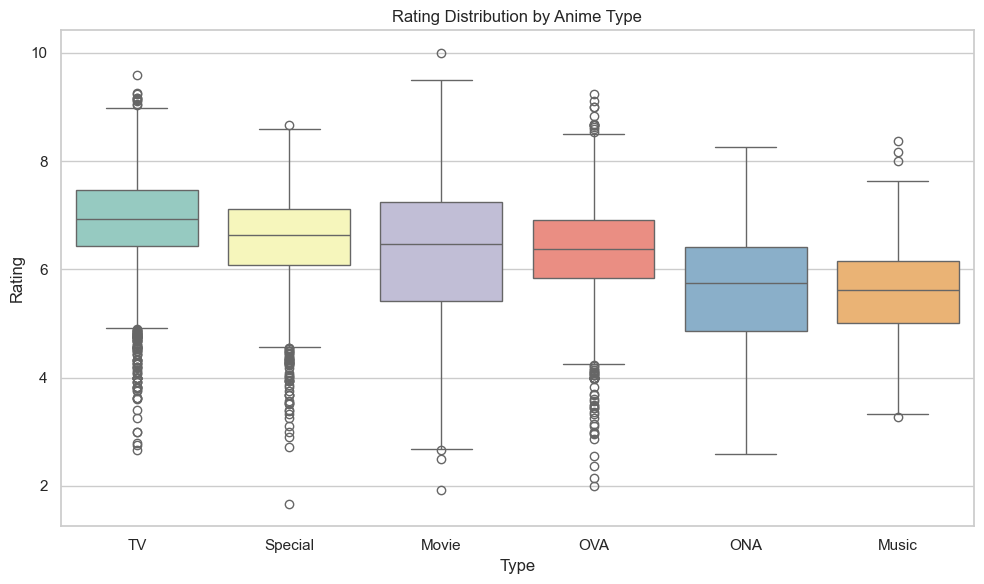

In [14]:
plt.figure(figsize=(10, 6))
order = df.groupby("type")["rating"].median().sort_values(ascending=False).index
sns.boxplot(x="type", y="rating", data=df, order=order, palette="Set3")
plt.title("Rating Distribution by Anime Type")
plt.xlabel("Type")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

# VISUALISATION 6 — Correlation Heatmap (Numerical Features)

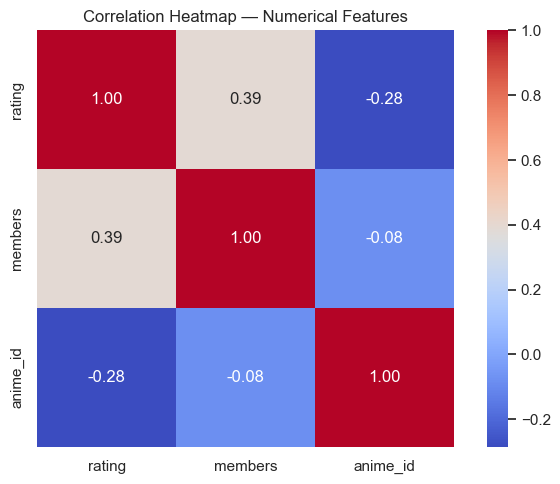

In [15]:
plt.figure(figsize=(7, 5))
sns.heatmap(df[["rating", "members", "anime_id"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()

# Task 2 — Feature Extraction & Engineering

In [16]:
# DROP ROWS WITH MISSING GENRE OR RATING
df_clean = df.dropna(subset=["genre", "rating"]).copy()
df_clean.reset_index(drop=True, inplace=True)

print(f"Rows before cleaning : {len(df)}")
print(f"Rows after  cleaning : {len(df_clean)}")
print(f"Removed              : {len(df) - len(df_clean)} rows")
print(f"Missing values remaining:\n{df_clean.isnull().sum()}")

Rows before cleaning : 12294
Rows after  cleaning : 12017
Removed              : 277 rows
Missing values remaining:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


In [17]:
# CLEAN EPISODES COLUMN
df_clean["episodes"] = pd.to_numeric(df_clean["episodes"], errors="coerce")
print("Episodes cleaned. Sample values:")
print(df_clean["episodes"].describe())

Episodes cleaned. Sample values:
count    11830.000000
mean        12.486729
std         47.097131
min          1.000000
25%          1.000000
50%          2.000000
75%         12.000000
max       1818.000000
Name: episodes, dtype: float64


In [18]:
# TF-IDF VECTORISATION OF GENRE
tfidf    = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(df_clean["genre"])

print(f"TF-IDF matrix shape : {tfidf_matrix.shape}")
print(f"  → {tfidf_matrix.shape[0]} anime × {tfidf_matrix.shape[1]} unique genre tokens")
print(f"Genre vocabulary size: {len(tfidf.vocabulary_)}")

TF-IDF matrix shape : (12017, 46)
  → 12017 anime × 46 unique genre tokens
Genre vocabulary size: 46


In [19]:
# NORMALISE RATING AND MEMBERS (MinMaxScaler)
scaler = MinMaxScaler()
rating_members_scaled = scaler.fit_transform(
    df_clean[["rating", "members"]].fillna(df_clean[["rating","members"]].median())
)

print("Normalisation complete.")
print(f"Scaled rating range  : {rating_members_scaled[:,0].min():.2f} – {rating_members_scaled[:,0].max():.2f}")
print(f"Scaled members range : {rating_members_scaled[:,1].min():.2f} – {rating_members_scaled[:,1].max():.2f}")

Normalisation complete.
Scaled rating range  : 0.00 – 1.00
Scaled members range : 0.00 – 1.00


In [20]:
# BUILD COMBINED FEATURE MATRIX
import scipy.sparse as sp

weight_genre   = 0.7
weight_numeric = 0.15

genre_weighted   = tfidf_matrix * weight_genre
numeric_matrix   = sp.csr_matrix(rating_members_scaled * weight_numeric)
combined_matrix  = sp.hstack([genre_weighted, numeric_matrix])

print(f"Combined feature matrix shape: {combined_matrix.shape}")
print(f"  Genre features   : {tfidf_matrix.shape[1]}  (weight={weight_genre})")
print(f"  Numeric features : 2  (rating + members, weight={weight_numeric} each)")

Combined feature matrix shape: (12017, 48)
  Genre features   : 46  (weight=0.7)
  Numeric features : 2  (rating + members, weight=0.15 each)


# Task 3 — Recommendation System (Cosine Similarity)

In [21]:
# COMPUTE COSINE SIMILARITY MATRIX
print("Computing cosine similarity matrix... (may take a moment)")
similarity_matrix = cosine_similarity(combined_matrix)
print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f"Sample similarity (row 0, top 5 values): {np.sort(similarity_matrix[0])[::-1][:5].round(4)}")

Computing cosine similarity matrix... (may take a moment)
Similarity matrix shape: (12017, 12017)
Sample similarity (row 0, top 5 values): [1.     0.9963 0.9959 0.9556 0.8753]


In [22]:
# BUILD ANIME TITLE → ROW INDEX MAP
df_clean = df_clean.reset_index(drop=True)
title_to_index = pd.Series(df_clean.index, index=df_clean["name"]).to_dict()

print(f"Index map built for {len(title_to_index)} anime titles.")
print("Sample entries:")
for title in list(title_to_index.items())[:3]:
    print(f"  '{title[0]}' → row {title[1]}")

Index map built for 12015 anime titles.
Sample entries:
  'Kimi no Na wa.' → row 0
  'Fullmetal Alchemist: Brotherhood' → row 1
  'Gintama°' → row 2


In [ ]:
# RECOMMENDATION FUNCTION — anime_recommendation()
def anime_recommendation(title, threshold=0.5, top_n=10):
    """
    Returns top-N anime recommendations similar to the given title.

    Parameters
    ----------
    title     : str   — name of the target anime (must exist in dataset)
    threshold : float — minimum cosine similarity score (0.0 to 1.0)
    top_n     : int   — maximum number of recommendations to return

    Returns
    -------
    DataFrame with recommended anime and their similarity scores.
    """
    # Step 1: Validate the title
    if title not in title_to_index:
        print(f"Anime '{title}' not found in dataset.")
        print("Did you mean one of these?")
        matches = [t for t in title_to_index if title.lower() in t.lower()][:5]
        for m in matches:
            print(f"  → {m}")
        return None

    # Step 2: Get the row index for this anime
    idx = title_to_index[title]

    # Step 3: Extract similarity scores for all anime vs this anime
    sim_scores = pd.Series(similarity_matrix[idx], index=df_clean.index)

    # Step 4: Filter — keep scores >= threshold, exclude the anime itself (score = 1.0 exactly)
    sim_scores = sim_scores[(sim_scores >= threshold) & (sim_scores.index != idx)]

    # Step 5: Sort by similarity descending and take top_n
    sim_scores = sim_scores.sort_values(ascending=False).head(top_n)

    if len(sim_scores) == 0:
        print(f"No anime found with similarity >= {threshold} for '{title}'.")
        print("Try lowering the threshold.")
        return None

    # Step 6: Build result DataFrame
    results = df_clean.loc[sim_scores.index, ["name", "genre", "type", "rating", "members"]].copy()
    results["similarity_score"] = sim_scores.values.round(4)
    results = results.reset_index(drop=True)
    results.index += 1   # start ranking from 1

    print(f"Top {len(results)} anime similar to \"{title}\" (threshold >= {threshold}):")
    print("-" * 70)
    return results


In [32]:
# DEMO 1 — Naruto with threshold = 0.5
result1 = anime_recommendation("Naruto", threshold=0.5, top_n=10)
result1

Top 10 anime similar to "Naruto" (threshold >= 0.5):
----------------------------------------------------------------------


,name,genre,type,rating,members,similarity_score
1,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,533578,0.9995
2,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.53,84527,0.9923
3,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.50,83515,0.9923
4,Boruto: Naruto the Movie,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,8.03,74690,0.9920
5,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,7.58,23465,0.9906
6,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.11,25174,0.9906
7,Boruto: Naruto the Movie - Naruto ga Hokage ni...,"Action, Comedy, Martial Arts, Shounen, Super P...",Special,7.68,16868,0.9905
8,Naruto Shippuuden: Sunny Side Battle,"Action, Comedy, Martial Arts, Shounen, Super P...",Special,7.26,13014,0.9903
9,Kyutai Panic Adventure!,"Action, Martial Arts, Shounen, Super Power",Special,5.21,700,0.9691
10,Naruto: Shippuuden Movie 6 - Road to Ninja,"Action, Adventure, Martial Arts, Shounen, Supe...",Movie,7.84,87369,0.9416


In [33]:
# DEMO 2 — Naruto with threshold = 0.9
result2 = anime_recommendation("Naruto", threshold=0.9, top_n=10)
result2

Top 10 anime similar to "Naruto" (threshold >= 0.9):
----------------------------------------------------------------------


,name,genre,type,rating,members,similarity_score
1,Naruto: Shippuuden,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,533578,0.9995
2,Naruto: Shippuuden Movie 4 - The Lost Tower,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.53,84527,0.9923
3,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.50,83515,0.9923
4,Boruto: Naruto the Movie,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,8.03,74690,0.9920
5,Naruto x UT,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,7.58,23465,0.9906
6,Naruto Soyokazeden Movie: Naruto to Mashin to ...,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.11,25174,0.9906
7,Boruto: Naruto the Movie - Naruto ga Hokage ni...,"Action, Comedy, Martial Arts, Shounen, Super P...",Special,7.68,16868,0.9905
8,Naruto Shippuuden: Sunny Side Battle,"Action, Comedy, Martial Arts, Shounen, Super P...",Special,7.26,13014,0.9903
9,Kyutai Panic Adventure!,"Action, Martial Arts, Shounen, Super Power",Special,5.21,700,0.9691
10,Naruto: Shippuuden Movie 6 - Road to Ninja,"Action, Adventure, Martial Arts, Shounen, Supe...",Movie,7.84,87369,0.9416


In [34]:
# DEMO 3 — Steins;Gate (Sci-Fi Thriller) with threshold = 0.5
result3 = anime_recommendation("Steins;Gate", threshold=0.5, top_n=10)
result3

Top 10 anime similar to "Steins;Gate" (threshold >= 0.5):
----------------------------------------------------------------------


,name,genre,type,rating,members,similarity_score
1,Steins;Gate Movie: Fuka Ryouiki no Déjà vu,"Sci-Fi, Thriller",Movie,8.61,192424,0.9950
2,Steins;Gate: Oukoubakko no Poriomania,"Sci-Fi, Thriller",Special,8.46,159548,0.9943
3,Steins;Gate: Kyoukaimenjou no Missing Link - D...,"Sci-Fi, Thriller",Special,8.34,38147,0.9912
4,Under the Dog,"Action, Sci-Fi, Thriller",OVA,6.55,29922,0.9357
5,Loups=Garous,"Mystery, Sci-Fi, Thriller",Movie,6.43,12350,0.8538
6,Loups=Garous Pilot,"Mystery, Sci-Fi, Thriller",Special,5.87,622,0.8522
7,Kyoto Animation: Megane-hen,Thriller,Special,6.51,5705,0.8280
8,Ibara no Ou,"Action, Mystery, Sci-Fi, Thriller",Movie,7.24,38670,0.8214
9,Duan Nao,"Mystery, Sci-Fi, Shounen, Thriller",ONA,6.42,1812,0.8057
10,Arve Rezzle: Kikaijikake no Yousei-tachi,"Action, Drama, Mystery, Sci-Fi, Thriller",Movie,6.44,18770,0.7802


In [35]:
# DEMO 4 — Fullmetal Alchemist: Brotherhood with threshold = 0.3
result4 = anime_recommendation("Fullmetal Alchemist: Brotherhood", threshold=0.3, top_n=15)
result4

Top 15 anime similar to "Fullmetal Alchemist: Brotherhood" (threshold >= 0.3):
----------------------------------------------------------------------


,name,genre,type,rating,members,similarity_score
1,Fullmetal Alchemist,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,8.33,600384,0.9739
2,Fullmetal Alchemist: The Sacred Star of Milos,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",Movie,7.50,87944,0.9632
3,Fullmetal Alchemist: Brotherhood Specials,"Adventure, Drama, Fantasy, Magic, Military, Sh...",Special,8.11,67962,0.9460
4,Tales of Vesperia: The First Strike,"Action, Adventure, Fantasy, Magic, Military",Movie,7.79,30524,0.8672
5,Tide-Line Blue,"Action, Adventure, Drama, Military, Shounen",TV,6.77,4670,0.8245
6,Fullmetal Alchemist: Reflections,"Adventure, Comedy, Drama, Fantasy, Military, S...",Special,7.39,24987,0.8056
7,Magi: The Labyrinth of Magic,"Action, Adventure, Fantasy, Magic, Shounen",TV,8.24,317513,0.7899
8,Magi: The Kingdom of Magic,"Action, Adventure, Fantasy, Magic, Shounen",TV,8.50,245026,0.7885
9,Densetsu no Yuusha no Densetsu,"Action, Adventure, Fantasy, Magic, Shounen",TV,7.83,130689,0.7844
10,Magi: Sinbad no Bouken (TV),"Action, Adventure, Fantasy, Magic, Shounen",TV,8.22,73480,0.7833


# VISUALISATION 7 — Threshold vs Number of Recommendations

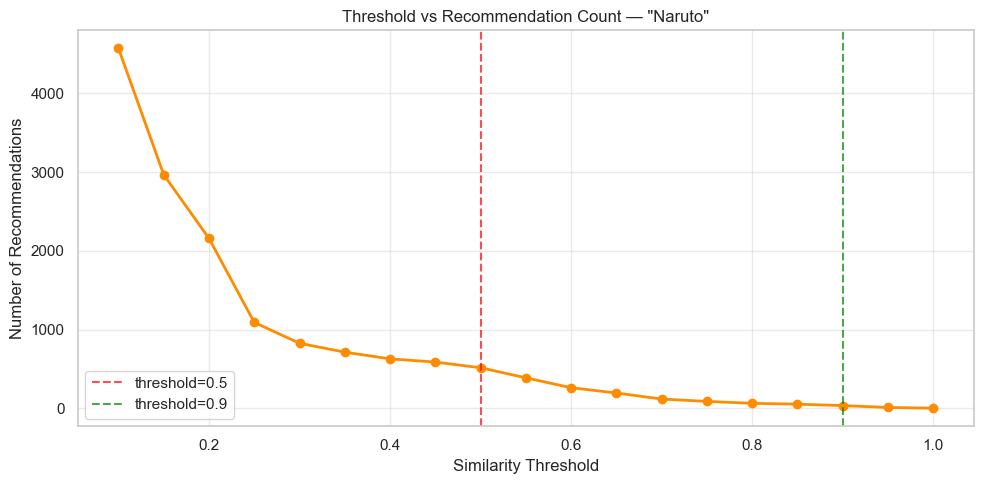

In [36]:
test_anime  = "Naruto"
thresholds  = np.arange(0.1, 1.01, 0.05)
counts      = []

idx = title_to_index[test_anime]
sim_scores_full = pd.Series(similarity_matrix[idx], index=df_clean.index)

for t in thresholds:
    n = ((sim_scores_full >= t) & (sim_scores_full.index != idx)).sum()
    counts.append(n)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, counts, marker="o", color="darkorange", linewidth=2)
plt.axvline(x=0.5, color="red",   linestyle="--", alpha=0.7, label="threshold=0.5")
plt.axvline(x=0.9, color="green", linestyle="--", alpha=0.7, label="threshold=0.9")
plt.xlabel("Similarity Threshold")
plt.ylabel("Number of Recommendations")
plt.title(f"Threshold vs Recommendation Count — \"{test_anime}\"")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


# VISUALISATION 8 — Similarity Heatmap (Top 15 Popular Anime)

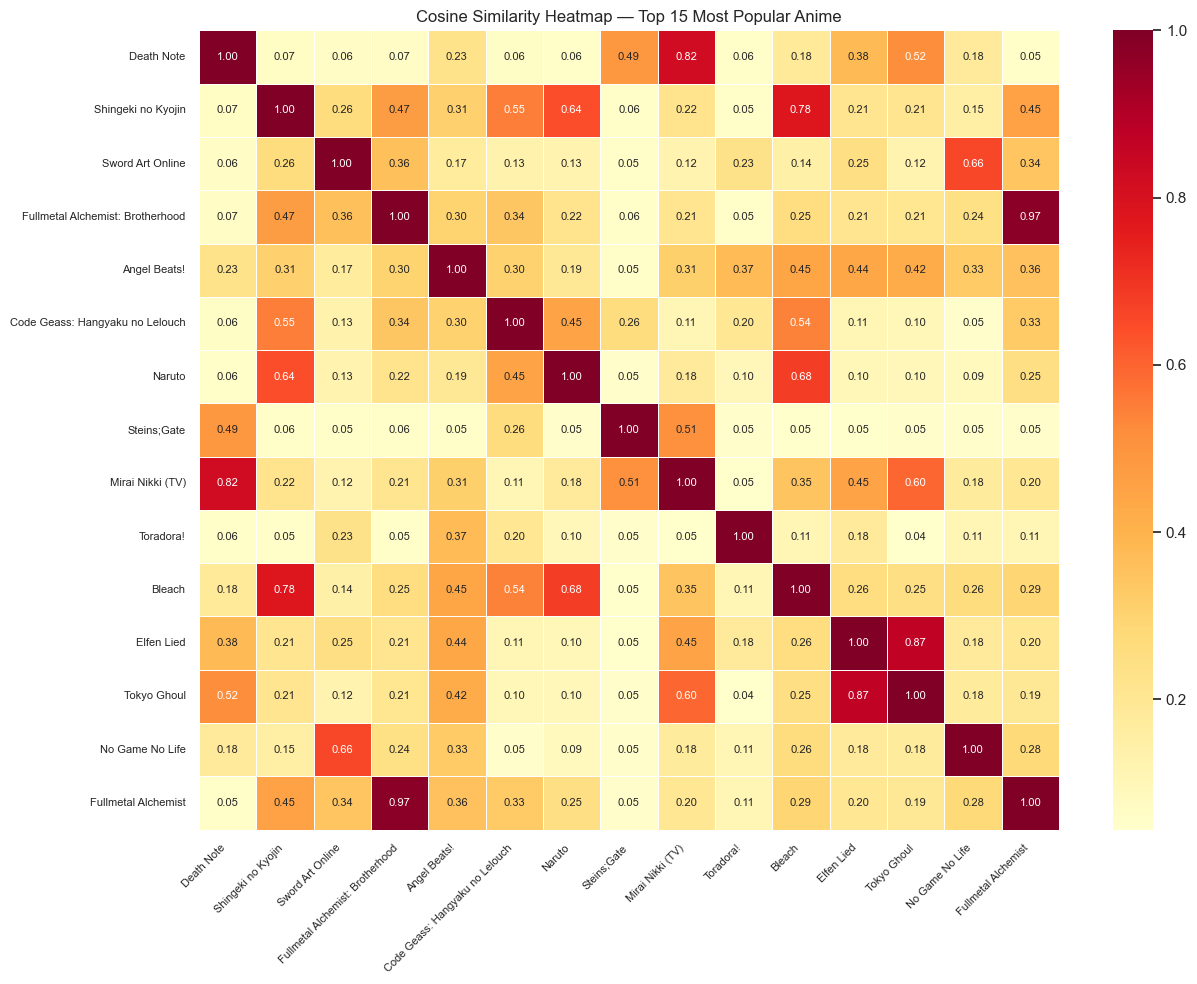

In [37]:
top15_titles = df_clean.nlargest(15, "members")["name"].tolist()
top15_indices = [title_to_index[t] for t in top15_titles if t in title_to_index]
top15_titles  = [df_clean.loc[i, "name"] for i in top15_indices]

sim_subset = similarity_matrix[np.ix_(top15_indices, top15_indices)]

plt.figure(figsize=(13, 10))
sns.heatmap(sim_subset, xticklabels=top15_titles, yticklabels=top15_titles,
            annot=True, fmt=".2f", cmap="YlOrRd",
            annot_kws={"size": 8}, linewidths=0.5)
plt.title("Cosine Similarity Heatmap — Top 15 Most Popular Anime")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


# VISUALISATION 9 — Distribution of Similarity Scores for a Target Anime

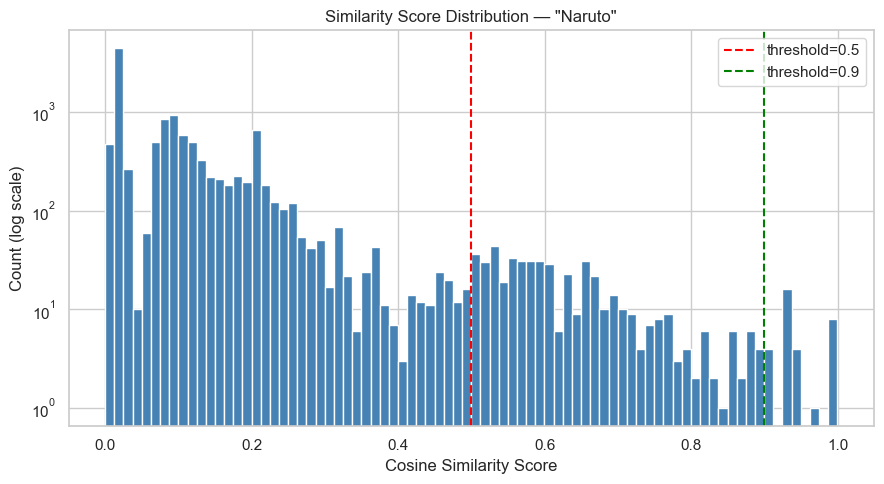

In [38]:
target = "Naruto"
idx    = title_to_index[target]
scores = similarity_matrix[idx].copy()
scores[idx] = 0   # exclude self-similarity

plt.figure(figsize=(9, 5))
plt.hist(scores, bins=80, color="steelblue", edgecolor="white", log=True)
plt.axvline(x=0.5, color="red",   linestyle="--", label="threshold=0.5")
plt.axvline(x=0.9, color="green", linestyle="--", label="threshold=0.9")
plt.title(f"Similarity Score Distribution — \"{target}\"")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Count (log scale)")
plt.legend()
plt.tight_layout()
plt.show()


## Interview Questions

#### 1. What is the difference between user-based and item-based collaborative filtering?

User-based collaborative filtering works by finding other users who have similar tastes to the target user. If you and another user have both rated the same set of anime highly, the system assumes you have similar preferences and recommends anime that the other user liked but you have not seen yet. The idea is that people with similar past behaviour will have similar future preferences.

Item-based collaborative filtering works the other way around. Instead of finding similar users, it finds items that are similar to items the user already liked. If you enjoyed Naruto, the system looks at what other anime tend to be rated highly by the same users who rated Naruto highly, and recommends those. It focuses on the relationships between items rather than between users.

The simple way to remember it is that user-based filtering says "people like you also liked this" while item-based filtering says "because you liked this, you might also like that". Item-based filtering is generally more stable and scalable because item similarity matrices change less frequently than user behaviour patterns.

#### 2. What is collaborative filtering and how does it work?

Collaborative filtering is a recommendation technique that makes predictions about what a user might like based on the collective behaviour and preferences of many users. It does not need any information about the content of the items themselves — it works purely from the pattern of who liked what.

The core idea is that if a large group of users tend to rate or interact with the same set of items in similar ways, their preferences are likely to be correlated in other areas too. The system collects these interaction patterns, builds a model of user-item relationships, and uses it to predict ratings or suggest items for users who have not yet interacted with them.

For example, if 500 users all rated Naruto and Attack on Titan highly, and a new user just rated Naruto highly, collaborative filtering would recommend Attack on Titan to that new user even without knowing anything about either anime's content or genre.